In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# start with some U_true and make it arrange.logpi

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
# centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [4]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

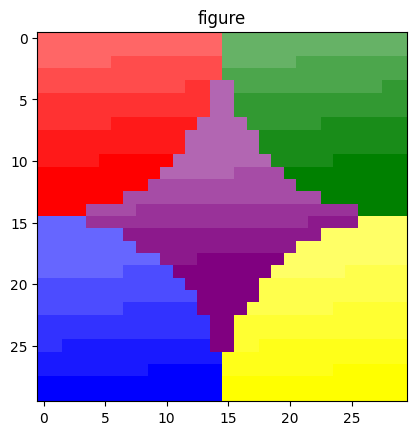

In [5]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

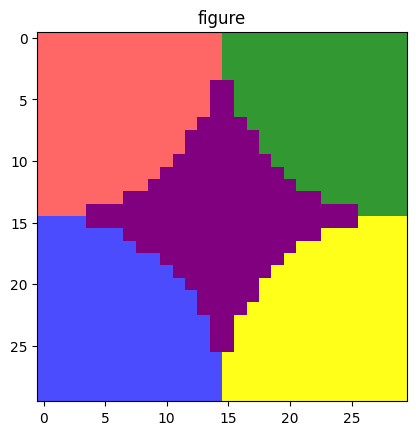

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
plot_Us(U_true_5)
U_true_5 = U_true_5[np.newaxis, :, :]

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

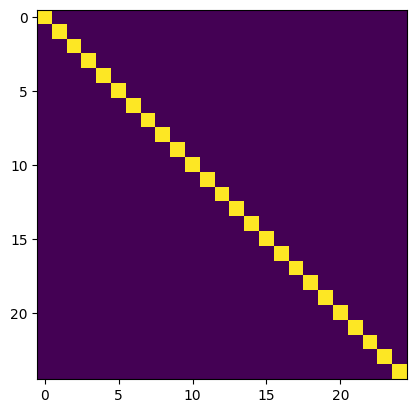

In [7]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.0001, sub_parcel_extra_correlation=0.001)
plt.imshow(R)


covariance across tasks G

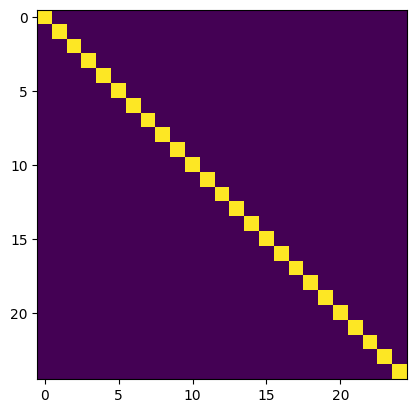

In [8]:
# variance_factors = [[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6]]
variance_factors = [[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]]
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.001, variance_factors=variance_factors)
plt.imshow(G)

make Vs (this num_iter gives a good V)

0.021219804486079036
0.021217167553235
0.021216788605916886
0.021215997171577433
0.021214831351847124
0.021214712864910133
0.021214483511791116
0.02121444794047484
0.02121332572263968


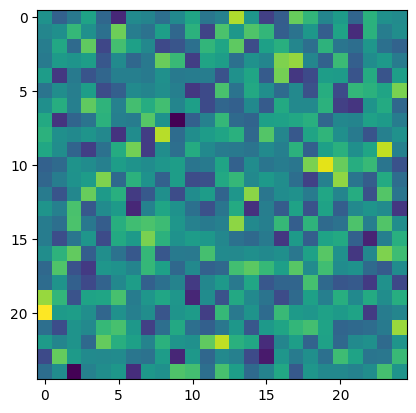

In [9]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=16000,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns

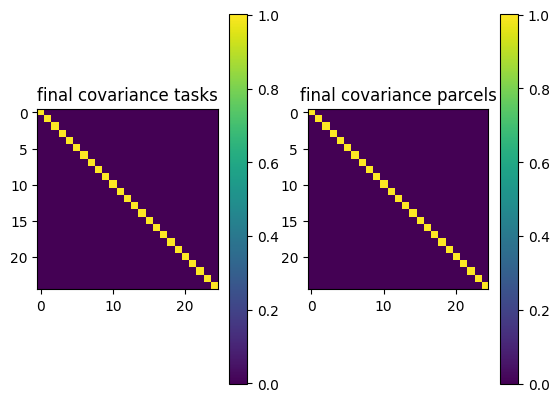

In [10]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()
plt.title('final covariance tasks')

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.title('final covariance parcels')
plt.show()


lower dimensional Vs (just for the 5 main parcels)

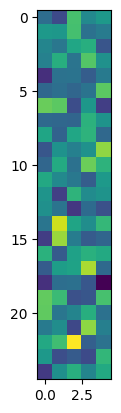

In [11]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data

In [12]:
Y_true = Vs_25 @ np.array(U_true_25)


G matrix used for eigenmetrics

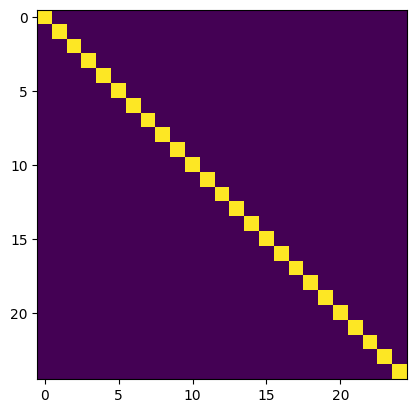

In [13]:
G_lib = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [ ]:
noise =0.15
vtest = Vs_5
ytest = Y_true + np.random.normal(0, noise, Y_true.shape)

: 

In [ ]:
D = ut.build_combinations(G_lib, strategy='balanced',n_iter=100,n_tasks=8,seed=605,balanced_sampling_unique=[2,3,4,5,6,7,8])
D_ev = ev.evaluate_dataframe_simulation_multiregion(D,Y_true, Vs_5, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)

building0


# Build model

0.8543590325498155


<Axes: xlabel='n_unique', ylabel='perc'>

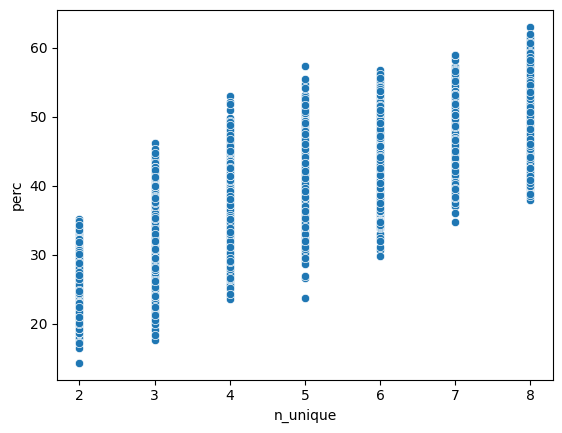

In [ ]:
#correaltion 
corr = np.corrcoef(D_ev['n_unique'],D_ev['perc'])[0,1]
print(corr)
sns.scatterplot(data=D_ev, x='n_unique', y='perc')

In [ ]:
n_unique_list = D_ev['n_unique'].unique()
n_unique_list.sort()
x = ['log_det','inverse_trace','variance']


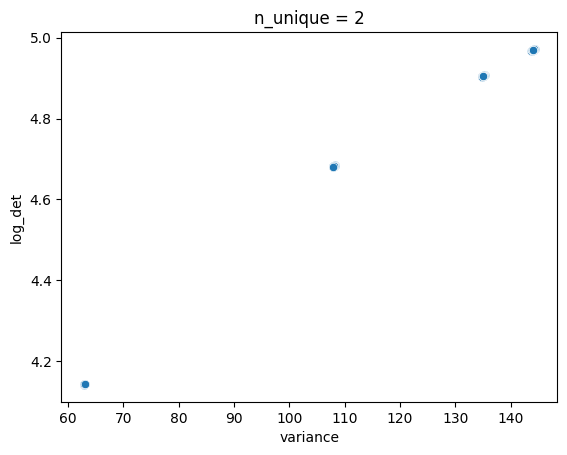

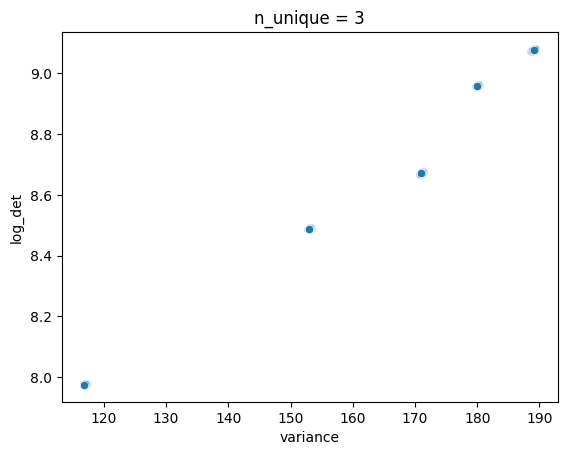

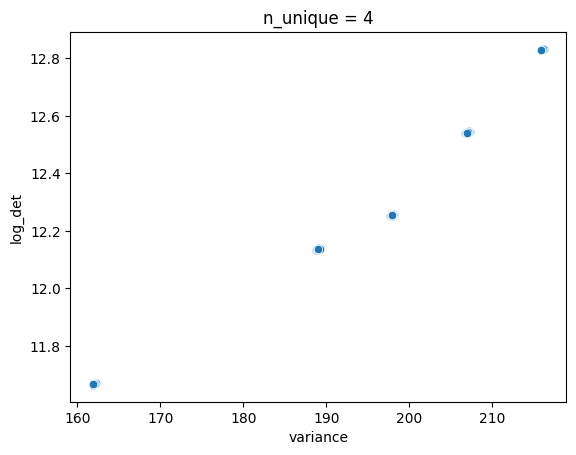

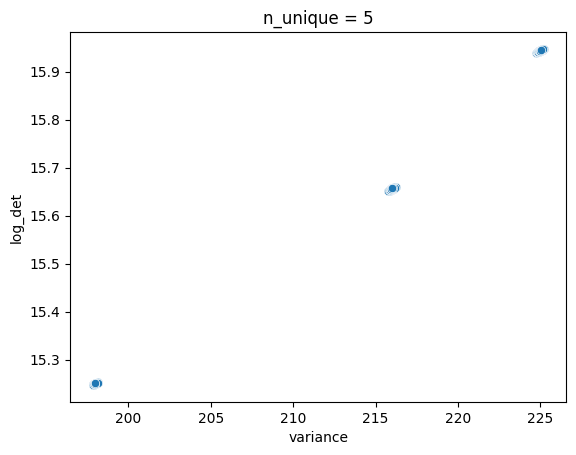

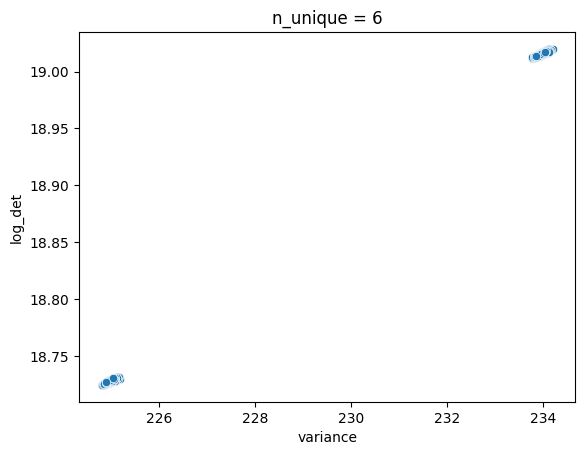

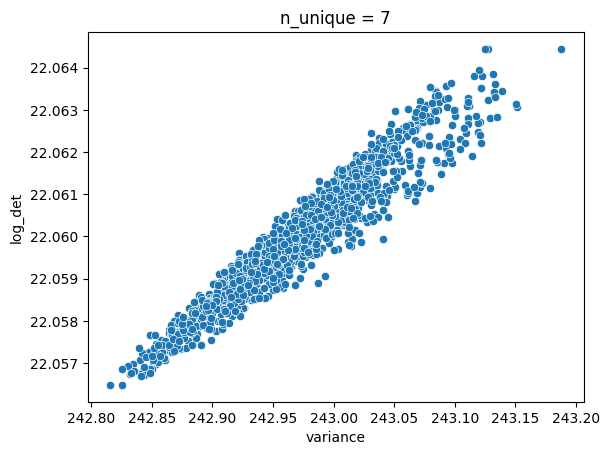

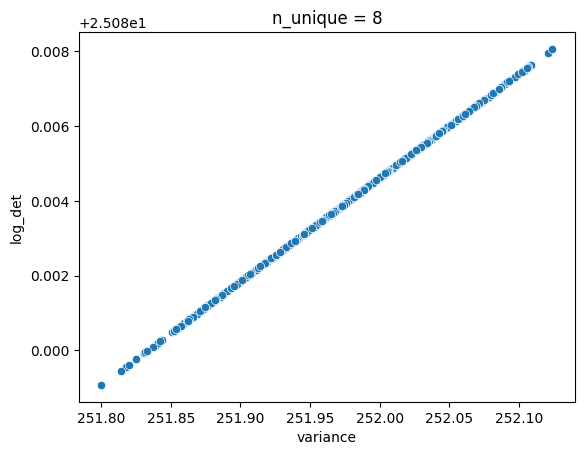

In [ ]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    plt.figure()
    sns.scatterplot(data=D_ev_temp, x='variance', y='log_det')
    plt.title('n_unique = {}'.format(i))
    plt.show()

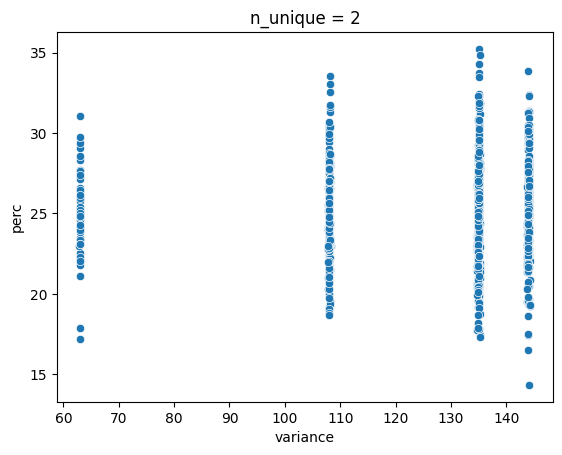

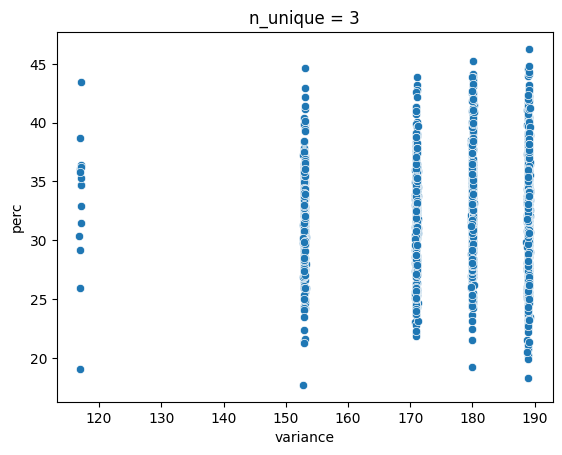

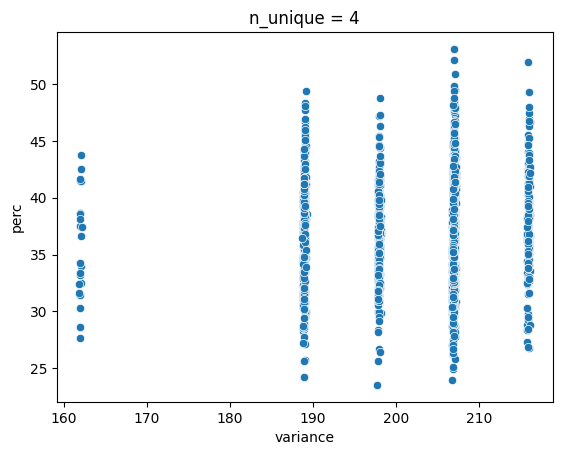

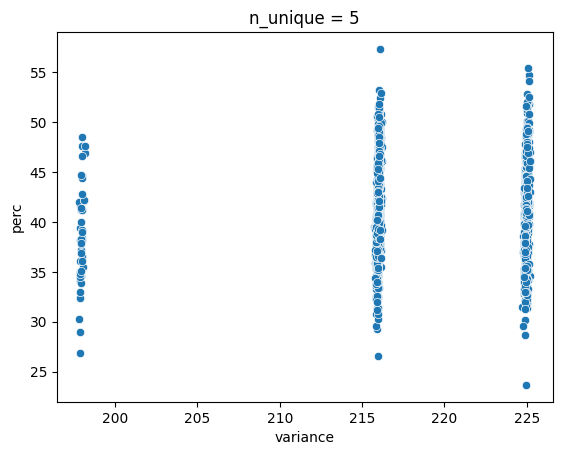

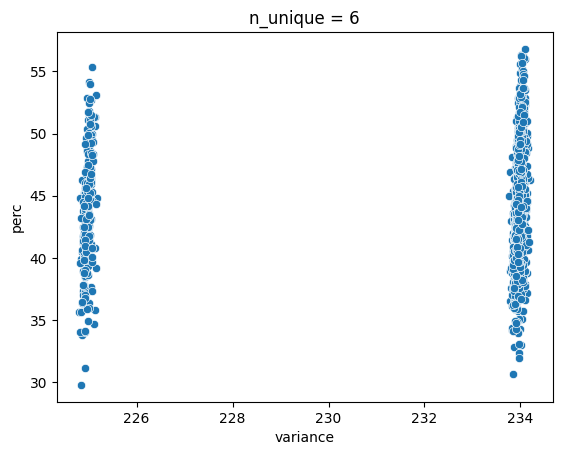

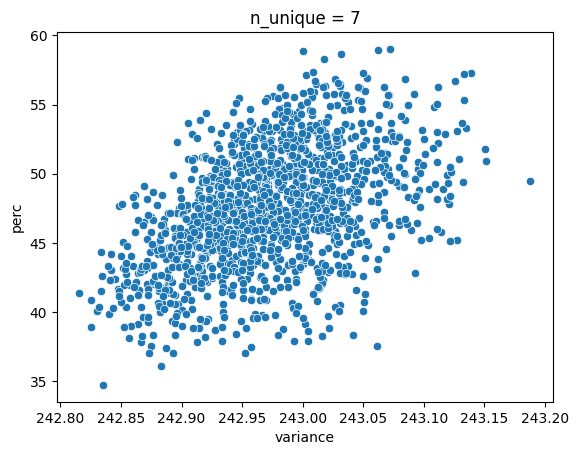

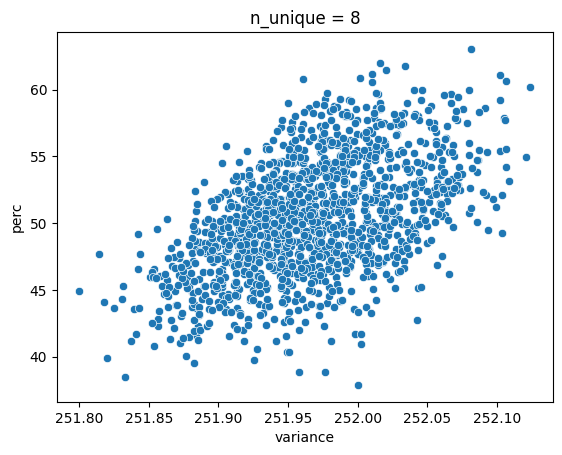

In [ ]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    plt.figure()
    sns.scatterplot(data=D_ev_temp, x='variance', y='perc')
    plt.title('n_unique = {}'.format(i))
    plt.show()

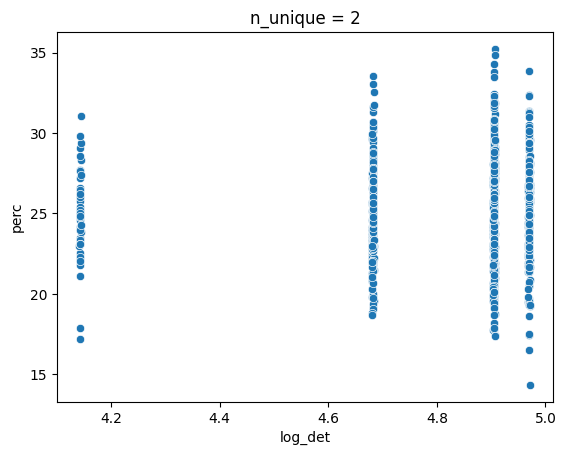

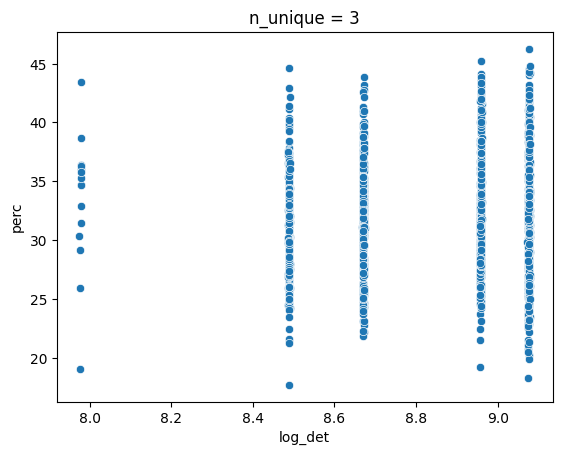

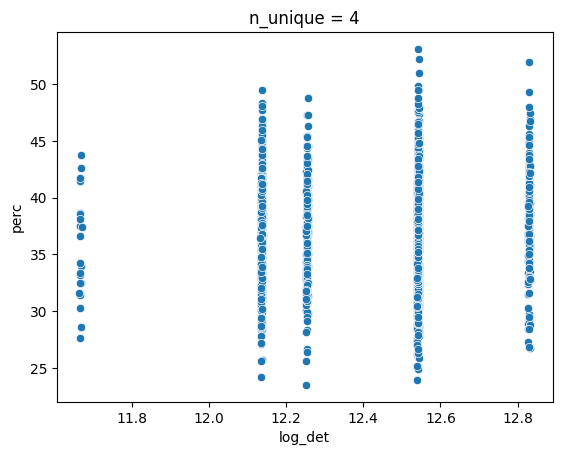

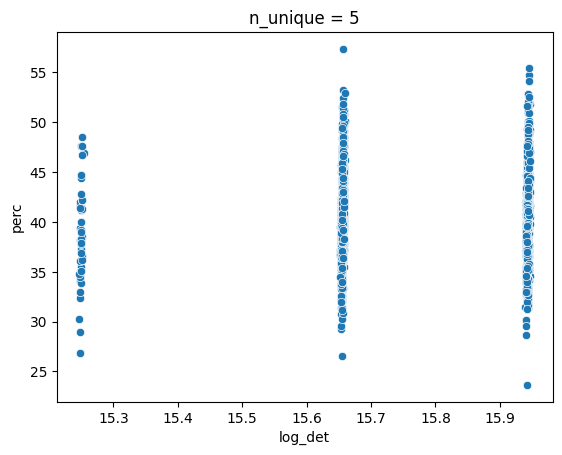

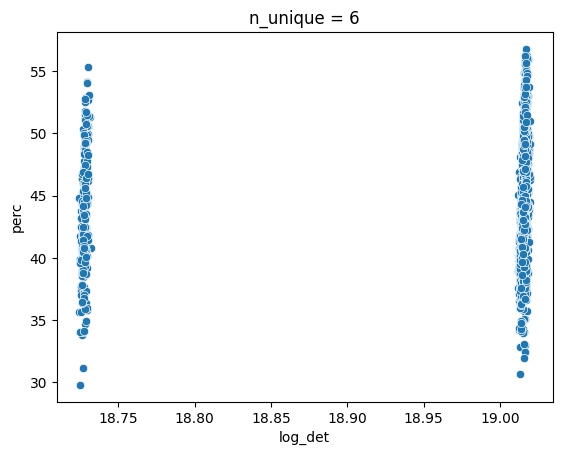

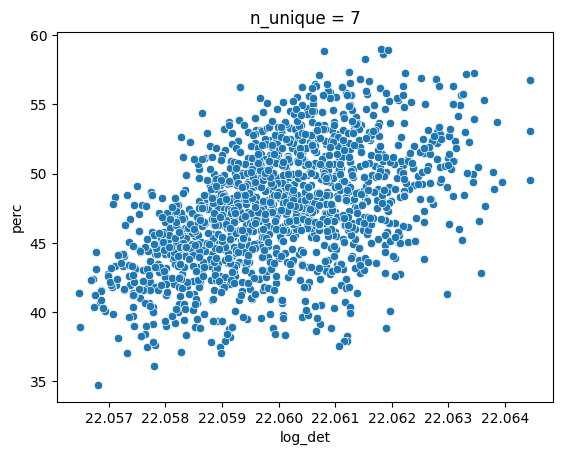

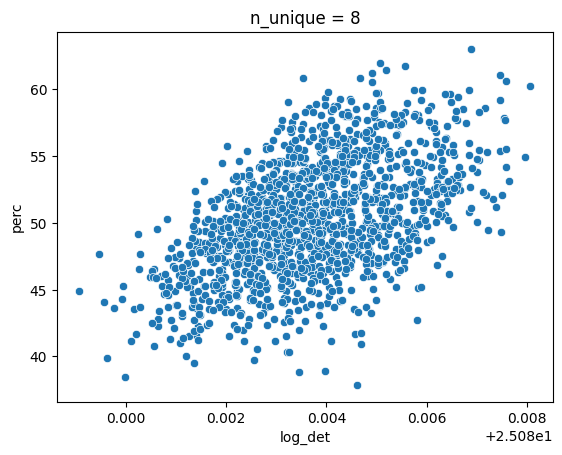

In [ ]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    plt.figure()
    sns.scatterplot(data=D_ev_temp, x='log_det', y='perc')
    plt.title('n_unique = {}'.format(i))
    plt.show()